<IPython.core.display.Javascript object>


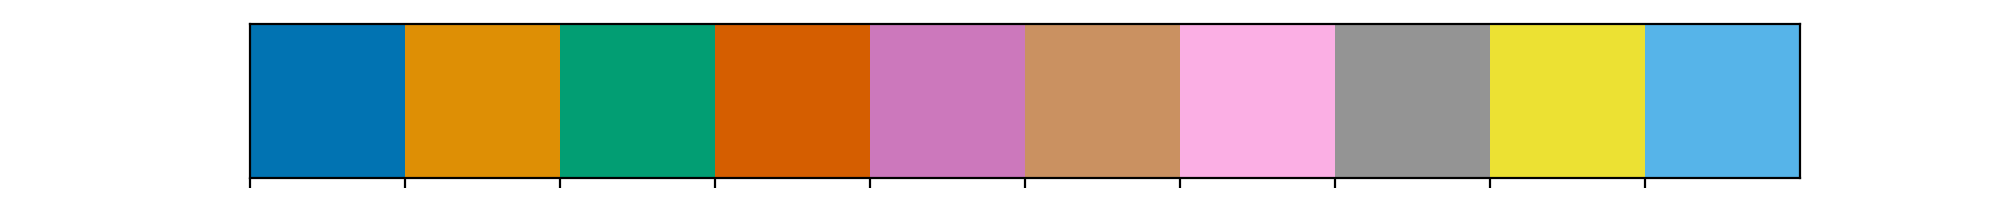

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.coordinates import Angle
import astropy.units as u
import pickle

from astropy.coordinates import SkyCoord

from scipy.interpolate import interp1d

pal = sns.color_palette("colorblind")

%matplotlib notebook

sns.palplot(pal)

# Load All Data

In [2]:
with open("FitResultsData/crn_fit_results.pkl", "rb") as f:
    (crn_track, crn_distance, crn_rgal, crn_ha_fit_results, crn_hi_fit_results) = pickle.load(f)
    
with open("FitResultsData/crf_fit_results.pkl", "rb") as f:
    (crf_track, crf_distance, crf_rgal, crf_ha_fit_results, crf_hi_fit_results) =  pickle.load(f)
    
with open("FitResultsData/ctn_fit_results.pkl", "rb") as f:
    (ctn_track, ctn_distance, ctn_rgal, ctn_ha_fit_results, ctn_hi_fit_results) = pickle.load(f)
    
with open("FitResultsData/per_fit_results_bayestar.pkl", "rb") as f:
    (per_track, per_ha_fit_results, per_hi_fit_results, per_hi_q3_fit_results) =  pickle.load(f)
    
with open("FitResultsData/sgn_fit_results.pkl", "rb") as f:
    (sgn_track, sgn_ha_fit_results, sgn_hi_fit_results) = pickle.load(f)
    
with open("FitResultsData/sgf_fit_results.pkl", "rb") as f:
    (sgf_track, sgf_ha_fit_results, sgf_hi_fit_results) = pickle.load(f)
    
with open("FitResultsData/scn_fit_results.pkl", "rb") as f:
    (scn_track, scn_ha_fit_results, scn_hi_fit_results) = pickle.load(f)
    
with open("FitResultsData/scf_fit_results.pkl", "rb") as f:
    (scf_track, scf_ha_fit_results, scf_hi_fit_results) = pickle.load(f)

## Longitude Velocity/Distance

<IPython.core.display.Javascript object>


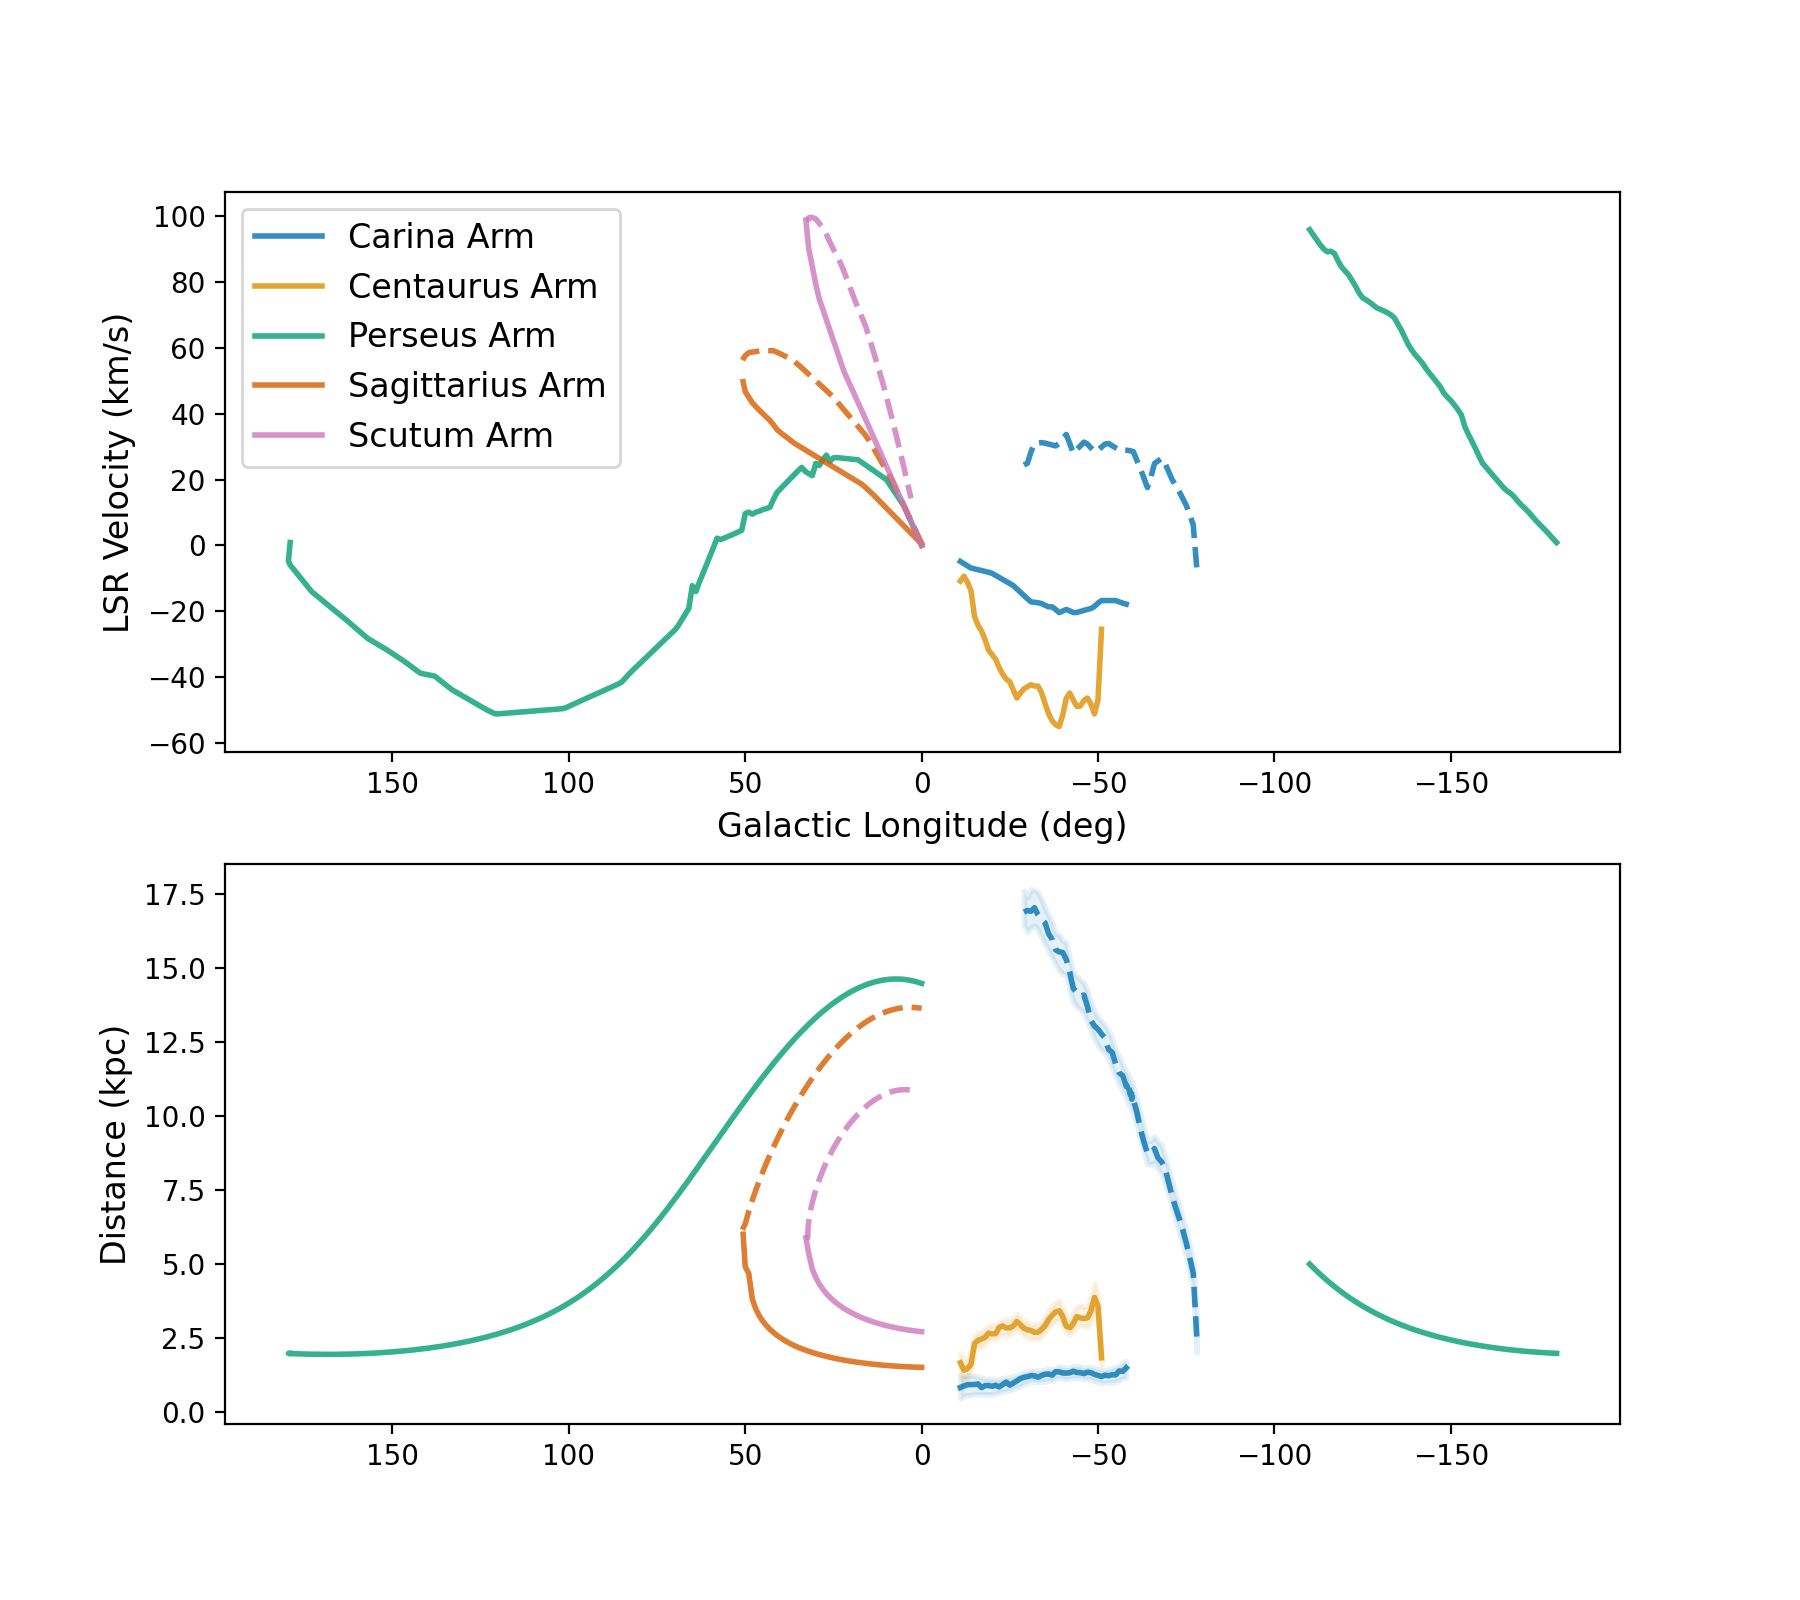

In [5]:
fig = plt.figure(figsize = (9,8))

ax = fig.add_subplot(211)
ax2 = fig.add_subplot(212, sharex = ax)

ax.set_xlabel("Galactic Longitude (deg)", fontsize = 12)
ax.set_ylabel("LSR Velocity (km/s)", fontsize = 12)
ax2.set_ylabel("Distance (kpc)", fontsize = 12)

ax.plot(Angle(crf_track[:,0]*u.deg).wrap_at("180d"), crf_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[0], ls = "--")
ax2.plot(Angle(crf_track[:,0]*u.deg).wrap_at("180d"), crf_distance[1], 
        lw = 2, alpha = 0.8, 
        color = pal[0], ls = "--")
ax2.fill_between(Angle(crf_track[:,0]*u.deg).wrap_at("180d").value, 
                 crf_distance[1] - crf_distance[0], 
                 crf_distance[1] + crf_distance[2], 
        lw = 2, alpha = 0.1, 
        color = pal[0])

ax.plot(Angle(crn_track[:,0]*u.deg).wrap_at("180d").value, crn_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[0], ls = "-", 
        label = "Carina Arm")
ax2.plot(Angle(crn_track[:,0]*u.deg).wrap_at("180d").value, crn_distance[1], 
        lw = 2, alpha = 0.8, 
        color = pal[0], ls = "-")
ax2.fill_between(Angle(crn_track[:,0]*u.deg).wrap_at("180d").value, 
                 crn_distance[1] - crn_distance[0], 
                 crn_distance[1] + crn_distance[2], 
        lw = 2, alpha = 0.1, 
        color = pal[0])

ax.plot(Angle(ctn_track[:,0]*u.deg).wrap_at("180d").value, ctn_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[1], ls = "-", 
        label = "Centaurus Arm")
ax2.plot(Angle(ctn_track[:,0]*u.deg).wrap_at("180d").value, ctn_distance[1], 
        lw = 2, alpha = 0.8, 
        color = pal[1], ls = "-")
ax2.fill_between(Angle(ctn_track[:,0]*u.deg).wrap_at("180d").value, 
                 ctn_distance[1] - ctn_distance[0], 
                 ctn_distance[1] + ctn_distance[2], 
        lw = 2, alpha = 0.1, 
        color = pal[1])


per_lon_mask = per_track[:,0] < 180
ax.plot(Angle(per_track[per_lon_mask,0]*u.deg).wrap_at("180d").value, per_track[per_lon_mask,2], 
        lw = 2, alpha = 0.8, 
        color = pal[2], ls = "-", 
        label = "Perseus Arm")
ax2.plot(Angle(per_track[per_lon_mask,0]*u.deg).wrap_at("180d").value, per_track[per_lon_mask,-1], 
        lw = 2, alpha = 0.8, 
        color = pal[2], ls = "-")

ax.plot(Angle(per_track[~per_lon_mask,0]*u.deg).wrap_at("180d").value, per_track[~per_lon_mask,2], 
        lw = 2, alpha = 0.8, 
        color = pal[2], ls = "-")
ax2.plot(Angle(per_track[~per_lon_mask,0]*u.deg).wrap_at("180d").value, per_track[~per_lon_mask,-1], 
        lw = 2, alpha = 0.8, 
        color = pal[2], ls = "-")


ax.plot(Angle(sgn_track[:,0]*u.deg).wrap_at("180d").value, sgn_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[3], ls = "-", 
        label = "Sagittarius Arm")
ax2.plot(Angle(sgn_track[:,0]*u.deg).wrap_at("180d").value, sgn_track[:,-1], 
        lw = 2, alpha = 0.8, 
        color = pal[3], ls = "-")

ax.plot(Angle(sgf_track[:,0]*u.deg).wrap_at("180d").value, sgf_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[3], ls = "--")
ax2.plot(Angle(sgf_track[:,0]*u.deg).wrap_at("180d").value, sgf_track[:,-1], 
        lw = 2, alpha = 0.8, 
        color = pal[3], ls = "--")

ax.plot(Angle(scn_track[:,0]*u.deg).wrap_at("180d").value, scn_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[4], ls = "-", 
        label = "Scutum Arm")
ax2.plot(Angle(scn_track[:,0]*u.deg).wrap_at("180d").value, scn_track[:,-1], 
        lw = 2, alpha = 0.8, 
        color = pal[4], ls = "-")

ax.plot(Angle(scf_track[:,0]*u.deg).wrap_at("180d").value, scf_track[:,2], 
        lw = 2, alpha = 0.8, 
        color = pal[4], ls = "--")
ax2.plot(Angle(scf_track[:,0]*u.deg).wrap_at("180d").value, scf_track[:,-1], 
        lw = 2, alpha = 0.8, 
        color = pal[4], ls = "--")



lg = ax.legend(fontsize = 12)
ax.invert_xaxis()

## Galactocentric Radius vs. Scale Heights

In [6]:
crn_rgal_interpolator = interp1d(crn_track[:,0], crn_rgal)
crn_rgal_smooth_ha = crn_rgal_interpolator(crn_ha_fit_results["smoothed_longitude"])
crn_rgal_smooth_hi = crn_rgal_interpolator(crn_hi_fit_results["smoothed_longitude"])

crf_rgal_interpolator = interp1d(crf_track[:,0], crf_rgal)
crf_rgal_smooth_ha = crf_rgal_interpolator(crf_ha_fit_results["smoothed_longitude"])
crf_rgal_smooth_hi = crf_rgal_interpolator(crf_hi_fit_results["smoothed_longitude"])

ctn_rgal_interpolator = interp1d(ctn_track[:,0], ctn_rgal)
ctn_rgal_smooth_ha = ctn_rgal_interpolator(ctn_ha_fit_results["smoothed_longitude"])
ctn_rgal_smooth_hi = ctn_rgal_interpolator(ctn_hi_fit_results["smoothed_longitude"])

per_rgal_interpolator = interp1d(per_track[:,0], per_track[:,3])
per_rgal_smooth_ha = per_rgal_interpolator(per_ha_fit_results["smoothed_longitude"])
per_rgal_smooth_hi = per_rgal_interpolator(per_hi_fit_results["smoothed_longitude"])
per_rgal_smooth_hi_q3 = per_rgal_interpolator(per_hi_q3_fit_results["smoothed_longitude"])

sgn_rgal_interpolator = interp1d(sgn_track[:,0], sgn_track[:,3])
sgn_rgal_smooth_ha = sgn_rgal_interpolator(sgn_ha_fit_results["smoothed_longitude"])
sgn_rgal_smooth_hi = sgn_rgal_interpolator(sgn_hi_fit_results["smoothed_longitude"])

sgf_rgal_interpolator = interp1d(sgf_track[:,0], sgf_track[:,3])
sgf_rgal_smooth_ha = sgf_rgal_interpolator(sgf_ha_fit_results["smoothed_longitude"])
sgf_rgal_smooth_hi = sgf_rgal_interpolator(sgf_hi_fit_results["smoothed_longitude"])

scn_rgal_interpolator = interp1d(scn_track[:,0], scn_track[:,3])
scn_rgal_smooth_ha = scn_rgal_interpolator(scn_ha_fit_results["smoothed_longitude"])
scn_rgal_smooth_hi = scn_rgal_interpolator(scn_hi_fit_results["smoothed_longitude"])

scf_rgal_interpolator = interp1d(scf_track[:,0], scf_track[:,3])
scf_rgal_smooth_ha = scf_rgal_interpolator(scf_ha_fit_results["smoothed_longitude"])
scf_rgal_smooth_hi = scf_rgal_interpolator(scf_hi_fit_results["smoothed_longitude"])

In [7]:
crn_ha_fit_results

{'median_longitude': array([302.41785, 303.05563, 303.4613 , 304.04745, 304.48154, 305.07166,
        305.50302, 306.0112 , 306.51892, 307.09213, 307.45312, 308.20386,
        308.4749 , 309.1475 , 309.53412, 310.11157, 310.60168, 310.98605,
        311.6506 , 312.0075 , 312.6422 , 313.0866 , 313.6387 , 314.09918,
        314.67114, 315.11435, 315.6282 , 316.10992, 316.65558, 317.20038,
        317.63315, 318.15158, 318.66058, 319.06015, 319.75272, 320.02045,
        320.75052, 321.02026, 321.7345 , 322.04974, 322.72046, 323.17953,
        323.70993, 324.268  , 324.70053, 325.25024, 325.71613, 326.1705 ,
        326.79034, 327.15045, 327.85034, 328.1764 , 328.86835, 329.21616,
        329.8638 , 330.21927, 330.8404 , 331.20987, 331.795  , 332.30215,
        332.75012, 333.40674, 333.73495, 334.42   , 334.72   , 335.39206,
        335.75845, 336.3993 , 336.85004, 337.29755, 337.8793 , 338.28897,
        338.89734, 339.3776 , 339.86   , 340.34793, 340.82306, 341.41986,
        341.8174 ,

<IPython.core.display.Javascript object>


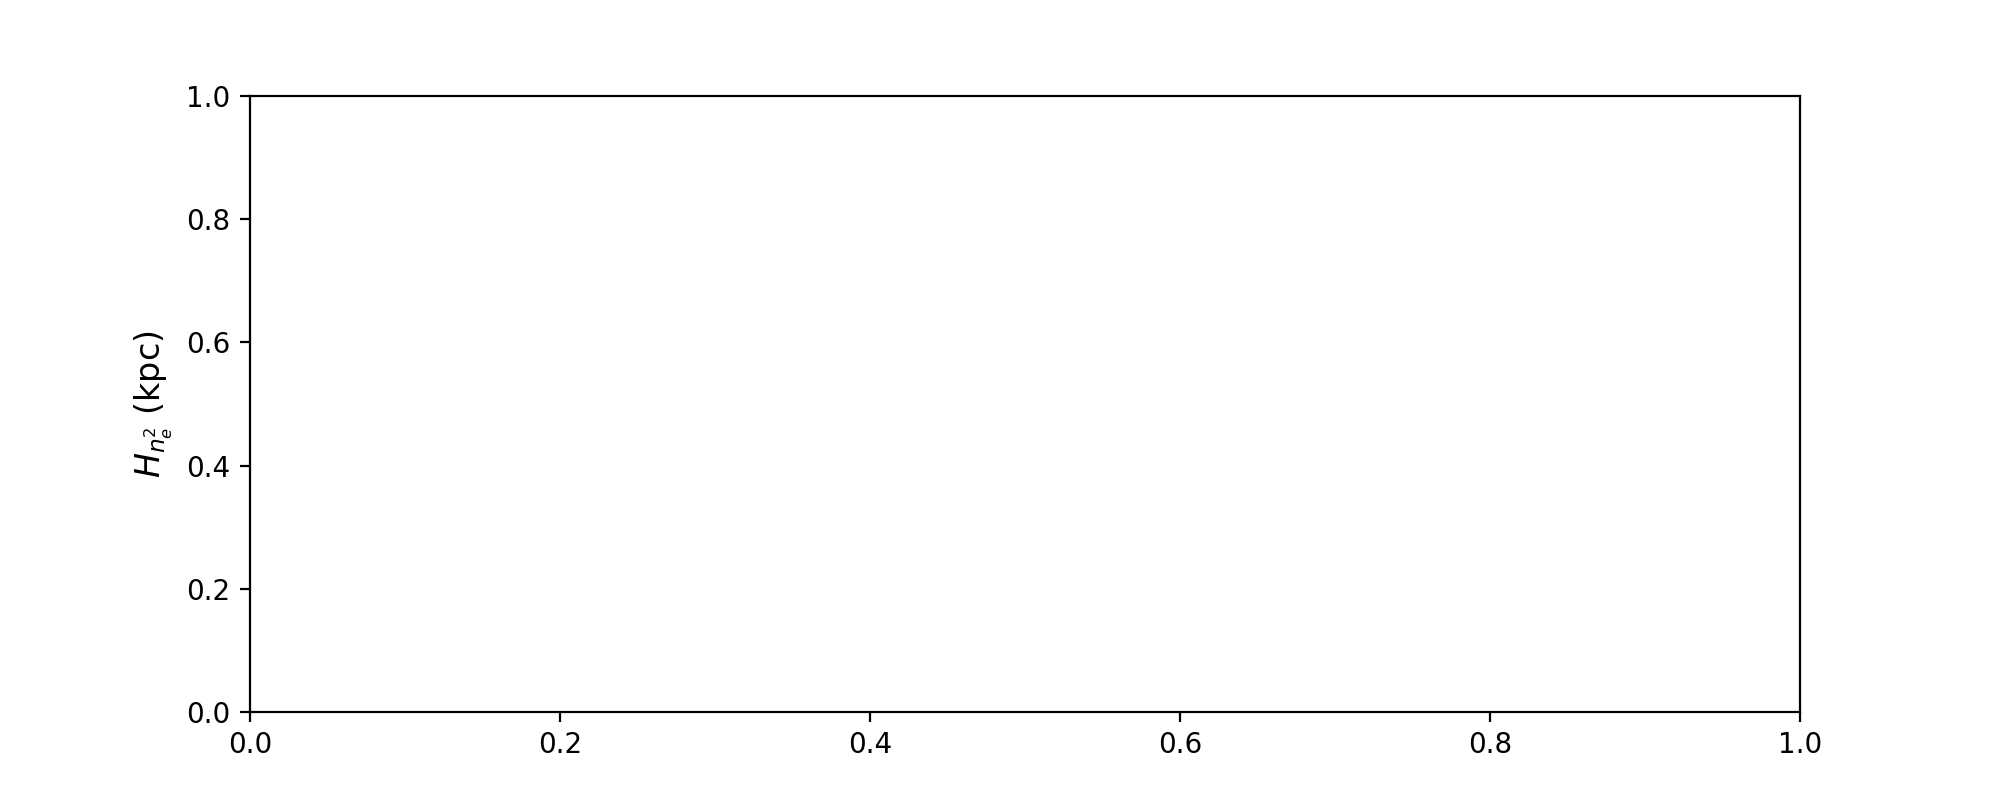

ValueError: 'yerr' must not contain negative values

In [8]:
fig = plt.figure(figsize = (10,4))

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel("$H_{{n_{{e}}^2}}$ (kpc)", fontsize = 12)

alpha = 0.3

# Carina Near
y = crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg"][0,:],
        crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crn_rgal_smooth_ha[0], crn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 20, markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos"][0,:],
        crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crn_rgal_smooth_ha[0], crn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 20, markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Carina Far
y = crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg"][1,:]
ypos = y>0
yerr = [y - crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg"][0,:],
        crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crf_rgal_smooth_ha[0], crf_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha[1][ypos], 
            y[ypos], 
            yerr = np.array(yerr)[:,ypos], xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos"][0,:],
        crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crf_rgal_smooth_ha[0], crf_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg"][0,:],
        ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [ctn_rgal_smooth_ha[0], ctn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos"][0,:],
        ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [ctn_rgal_smooth_ha[0], ctn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sagittarius Near
lon_mask = (sgn_ha_fit_results["smoothed_longitude"] < 50) & (sgn_ha_fit_results["smoothed_longitude"] > 18)
y = sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg"][0,:],
        sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos"][0,:],
        sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Sagittarius Far
lon_mask = (sgf_ha_fit_results["smoothed_longitude"] < 50) & (sgf_ha_fit_results["smoothed_longitude"] > 30)
y = sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg"][0,:],
        sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos"][0,:],
        sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Scutum Near
lon_mask = (scn_ha_fit_results["smoothed_longitude"] < 32) & (scn_ha_fit_results["smoothed_longitude"] > 15)
y = scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg"][0,:],
        scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos"][0,:],
        scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Perseus
lon_mask = (per_ha_fit_results["smoothed_longitude"] >90) & (per_ha_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_ha_fit_results["smoothed_longitude"] >190)
y = per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg"][0,:],
        per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos"][0,:],
        per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 12)

ax2.set_xlim(xlim)
ax2.set_ylim(0, 6)



ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"H$\alpha$ Spiral Arm Scale Heights", fontsize = 12)
plt.tight_layout()

# plt.savefig("RGal_v_HA_ScaleHeight.png", dpi = 300, transparent = True)

In [ ]:
fig = plt.figure(figsize = (10,4))

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()

# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)

alpha = 0.3

# Carina Near
y = crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"][0,:],
        crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crn_rgal_smooth_hi[0], crn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 30, markevery = 15)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"][0,:],
        crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crn_rgal_smooth_hi[0], crn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 30, markevery = 15)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Carina Far
y = crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"][1,:]
ypos = y>0
yerr = [y - crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"][0,:],
        crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crf_rgal_smooth_hi[0], crf_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi[1][ypos], 
            y[ypos], 
            yerr = np.array(yerr)[:,ypos], xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"][0,:],
        crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crf_rgal_smooth_hi[0], crf_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"][0,:],
        ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [ctn_rgal_smooth_hi[0], ctn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"][0,:],
        ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [ctn_rgal_smooth_hi[0], ctn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sagittarius Near
lon_mask = (sgn_hi_fit_results["smoothed_longitude"] < 50) & (sgn_hi_fit_results["smoothed_longitude"] > 18)
y = sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"][0,:],
        sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"][0,:],
        sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Sagittarius Far
lon_mask = (sgf_hi_fit_results["smoothed_longitude"] < 50) & (sgf_hi_fit_results["smoothed_longitude"] > 30)
y = sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"][0,:],
        sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"][0,:],
        sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Scutum Near
lon_mask = (scn_hi_fit_results["smoothed_longitude"] < 32) & (scn_hi_fit_results["smoothed_longitude"] > 15)
y = scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"][0,:],
        scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"][0,:],
        scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Perseus
lon_mask = (per_hi_fit_results["smoothed_longitude"] >90) & (per_hi_fit_results["smoothed_longitude"] <170)
y = per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"][0,:],
        per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"][0,:],
        per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

lon_mask = (per_hi_q3_fit_results["smoothed_longitude"] >190)
y = per_hi_q3_fit_results["smoothed_distance"] / per_hi_q3_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - per_hi_q3_fit_results["smoothed_distance"] / per_hi_q3_fit_results["smoothed_slopes_neg"][0,:],
        per_hi_q3_fit_results["smoothed_distance"] / per_hi_q3_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi_q3[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_hi_q3_fit_results["smoothed_distance"] / -per_hi_q3_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - per_hi_q3_fit_results["smoothed_distance"] / -per_hi_q3_fit_results["smoothed_slopes_pos"][0,:],
        per_hi_q3_fit_results["smoothed_distance"] / -per_hi_q3_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi_q3[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 12)

ax2.set_xlim(xlim)
ax2.set_ylim(0, 3)

ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"HI Spiral Arm Scale Heights", fontsize = 12)

plt.tight_layout()
# plt.savefig("RGal_v_HI_ScaleHeight.png", dpi = 300, transparent = True)

In [ ]:
fig = plt.figure(figsize = (10,8))

ax2 = fig.add_subplot(211)
# ax2 = ax.twinx()

ax.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel("$H_{{n_{{e}}^2}}$ (kpc)", fontsize = 12)

alpha = 0.3

# Carina Near
y = crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg"][0,:],
        crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crn_rgal_smooth_ha[0], crn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 20, markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos"][0,:],
        crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crn_rgal_smooth_ha[0], crn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 20, markevery = 10)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Carina Far
y = crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg"][1,:]
ypos = y>0
yerr = [y - crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg"][0,:],
        crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crf_rgal_smooth_ha[0], crf_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha[1][ypos], 
            y[ypos], 
            yerr = np.array(yerr)[:,ypos], xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos"][0,:],
        crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crf_rgal_smooth_ha[0], crf_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg"][0,:],
        ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [ctn_rgal_smooth_ha[0], ctn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos"][0,:],
        ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [ctn_rgal_smooth_ha[0], ctn_rgal_smooth_ha[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_ha[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sagittarius Near
lon_mask = (sgn_ha_fit_results["smoothed_longitude"] < 50) & (sgn_ha_fit_results["smoothed_longitude"] > 18)
y = sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg"][0,:],
        sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos"][0,:],
        sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Sagittarius Far
lon_mask = (sgf_ha_fit_results["smoothed_longitude"] < 50) & (sgf_ha_fit_results["smoothed_longitude"] > 30)
y = sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg"][0,:],
        sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos"][0,:],
        sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Scutum Near
lon_mask = (scn_ha_fit_results["smoothed_longitude"] < 32) & (scn_ha_fit_results["smoothed_longitude"] > 15)
y = scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg"][0,:],
        scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos"][0,:],
        scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]




# Perseus
lon_mask = (per_ha_fit_results["smoothed_longitude"] >90) & (per_ha_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_ha_fit_results["smoothed_longitude"] >190)
y = per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg"][0,:],
        per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos"][0,:],
        per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_ha[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)

# lg = ax2.legend(fontsize = 12)

ax2.set_xlim(xlim)
ax2.set_ylim(0, 6)




ax2.set_title(r"H$\alpha$ Spiral Arm Scale Heights", fontsize = 12)




ax2 = fig.add_subplot(212, sharex = ax2)

ax2.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)


alpha = 0.3

# Carina Near
y = crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"][0,:],
        crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crn_rgal_smooth_hi[0], crn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 30, markevery = 15)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"][0,:],
        crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crn_rgal_smooth_hi[0], crn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 30, markevery = 15)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Carina Far
y = crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"][1,:]
ypos = y>0
yerr = [y - crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"][0,:],
        crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [crf_rgal_smooth_hi[0], crf_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi[1][ypos], 
            y[ypos], 
            yerr = np.array(yerr)[:,ypos], xerr = None,
            fmt = "o", color = "b", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"][0,:],
        crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [crf_rgal_smooth_hi[0], crf_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(crf_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "o", color = "r", 
            alpha = alpha, errorevery = 6, markevery = 2)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Centaurus Near
y = ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"][0,:],
        ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
xerr = [ctn_rgal_smooth_hi[0], ctn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"][0,:],
        ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
xerr = [ctn_rgal_smooth_hi[0], ctn_rgal_smooth_hi[2]]
markers, caps, bars = ax2.errorbar(ctn_rgal_smooth_hi[1], 
            y, 
            yerr = yerr, xerr = None,
            fmt = "v", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


# Sagittarius Near
lon_mask = (sgn_hi_fit_results["smoothed_longitude"] < 50) & (sgn_hi_fit_results["smoothed_longitude"] > 18)
y = sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"][0,:],
        sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"][0,:],
        sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Sagittarius Far
lon_mask = (sgf_hi_fit_results["smoothed_longitude"] < 50) & (sgf_hi_fit_results["smoothed_longitude"] > 30)
y = sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"][0,:],
        sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "b", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"][0,:],
        sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(sgf_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "s", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Scutum Near
lon_mask = (scn_hi_fit_results["smoothed_longitude"] < 32) & (scn_hi_fit_results["smoothed_longitude"] > 15)
y = scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"][0,:],
        scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"][0,:],
        scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(scn_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "P", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

# Perseus
lon_mask = (per_hi_fit_results["smoothed_longitude"] >90) & (per_hi_fit_results["smoothed_longitude"] <170)
y = per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"][0,:],
        per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"][0,:],
        per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

lon_mask = (per_hi_q3_fit_results["smoothed_longitude"] >190)
y = per_hi_q3_fit_results["smoothed_distance"] / per_hi_q3_fit_results["smoothed_slopes_neg"][1,:]
yerr = [y - per_hi_q3_fit_results["smoothed_distance"] / per_hi_q3_fit_results["smoothed_slopes_neg"][0,:],
        per_hi_q3_fit_results["smoothed_distance"] / per_hi_q3_fit_results["smoothed_slopes_neg"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi_q3[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "b",
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]

y = per_hi_q3_fit_results["smoothed_distance"] / -per_hi_q3_fit_results["smoothed_slopes_pos"][1,:]
yerr = [y - per_hi_q3_fit_results["smoothed_distance"] / -per_hi_q3_fit_results["smoothed_slopes_pos"][0,:],
        per_hi_q3_fit_results["smoothed_distance"] / -per_hi_q3_fit_results["smoothed_slopes_pos"][2,:] - y]
markers, caps, bars = ax2.errorbar(per_rgal_smooth_hi_q3[lon_mask], 
            y[lon_mask], 
            yerr = np.array(yerr)[:,lon_mask], xerr = None,
            fmt = "x", color = "r", 
            alpha = alpha, errorevery = 10, markevery = 5)

[bar.set_alpha(0.2) for bar in bars]
[cap.set_alpha(0.2) for cap in caps]


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 100, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 100, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 12)

ax2.set_xlim(xlim)
ax2.set_ylim(0, 3)

ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"HI Spiral Arm Scale Heights", fontsize = 12)






plt.tight_layout()



# plt.savefig("RGal_v_HA_HI_ScaleHeight.png", dpi = 300, transparent = True)

# Face-On "Map" of H-Alpha

In [ ]:
galcen_distance = 8.127*u.kpc

crf_c_gal = SkyCoord(l = crf_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(crf_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = crf_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

crn_c_gal = SkyCoord(l = crn_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(crn_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = crn_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

ctn_c_gal = SkyCoord(l = ctn_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(ctn_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = ctn_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

per_c_gal = SkyCoord(l = per_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(per_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = per_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

sgf_c_gal = SkyCoord(l = sgf_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(sgf_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = sgf_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

sgn_c_gal = SkyCoord(l = sgn_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(sgn_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = sgn_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic", 
                     galcen_distance = galcen_distance)

scf_c_gal = SkyCoord(l = scf_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(scf_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = scf_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic", 
                     galcen_distance = galcen_distance)

scn_c_gal = SkyCoord(l = scn_ha_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(scn_ha_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = scn_ha_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",  
                     galcen_distance = galcen_distance)

In [ ]:
#Transform to Galactocentric Frame

crf_gc = crf_c_gal.transform_to("galactocentric")
crn_gc = crn_c_gal.transform_to("galactocentric")

ctn_gc = ctn_c_gal.transform_to("galactocentric")

per_gc = per_c_gal.transform_to("galactocentric")

sgf_gc = sgf_c_gal.transform_to("galactocentric")
sgn_gc = sgn_c_gal.transform_to("galactocentric")

scf_gc = scf_c_gal.transform_to("galactocentric")
scn_gc = scn_c_gal.transform_to("galactocentric")

In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 5
alpha = 0.7
    
# Carina Arm
height_pos = crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_pos = crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_pos = ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_ha_fit_results["smoothed_longitude"] >90) & (per_ha_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_ha_fit_results["smoothed_longitude"] >190)
height_pos = per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_ha_fit_results["smoothed_longitude"] < 60) & (sgf_ha_fit_results["smoothed_longitude"] > 30)
height_pos = sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_ha_fit_results["smoothed_longitude"] < 60) & (sgn_ha_fit_results["smoothed_longitude"] > 18)
height_pos = sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask],  
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_pos = scf_ha_fit_results["smoothed_distance"] / -scf_ha_fit_results["smoothed_slopes_pos_dr"]
# offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_pos[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_ha_fit_results["smoothed_longitude"] < 32) & (scn_ha_fit_results["smoothed_longitude"] > 15)
height_pos = scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
points = ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("r")
        
ax.set_title(r"H$\alpha$ Scale Height $b > 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{n_{{e}}^2}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()
# plt.savefig("Figures/FaceOn_HA_PositiveLatitude.png", dpi = 300, transparent = True)


In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 5
alpha = 0.7
    
# Carina Arm
height_neg = crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_neg = crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_neg = ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_ha_fit_results["smoothed_longitude"] >90) & (per_ha_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_ha_fit_results["smoothed_longitude"] >190)
height_neg = per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_ha_fit_results["smoothed_longitude"] < 60) & (sgf_ha_fit_results["smoothed_longitude"] > 30)
height_neg = sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_ha_fit_results["smoothed_longitude"] < 60) & (sgn_ha_fit_results["smoothed_longitude"] > 18)
height_neg = sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask],  
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_neg = scf_ha_fit_results["smoothed_distance"] / -scf_ha_fit_results["smoothed_slopes_neg_dr"]
# offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_neg[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_ha_fit_results["smoothed_longitude"] < 32) & (scn_ha_fit_results["smoothed_longitude"] > 15)
height_neg = scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
points = ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("b")

xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)


ax.set_title(r"H$\alpha$ Scale Height $b < 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{n_{{e}}^2}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()


# plt.savefig("Figures/FaceOn_HA_NegitiveLatitude.png", dpi = 300, transparent = True)


## Finer Scale Versions

In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 1.5
alpha = 0.7
    
# Carina Arm
height_pos = crf_ha_fit_results["smoothed_distance"] / -crf_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_pos = crn_ha_fit_results["smoothed_distance"] / -crn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_pos = ctn_ha_fit_results["smoothed_distance"] / -ctn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_ha_fit_results["smoothed_longitude"] >90) & (per_ha_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_ha_fit_results["smoothed_longitude"] >190)
height_pos = per_ha_fit_results["smoothed_distance"] / -per_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_ha_fit_results["smoothed_longitude"] < 60) & (sgf_ha_fit_results["smoothed_longitude"] > 30)
height_pos = sgf_ha_fit_results["smoothed_distance"] / -sgf_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_ha_fit_results["smoothed_longitude"] < 60) & (sgn_ha_fit_results["smoothed_longitude"] > 18)
height_pos = sgn_ha_fit_results["smoothed_distance"] / -sgn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask],  
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_pos = scf_ha_fit_results["smoothed_distance"] / -scf_ha_fit_results["smoothed_slopes_pos_dr"]
# offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_pos[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_ha_fit_results["smoothed_longitude"] < 32) & (scn_ha_fit_results["smoothed_longitude"] > 15)
height_pos = scn_ha_fit_results["smoothed_distance"] / -scn_ha_fit_results["smoothed_slopes_pos_dr"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
points = ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("r")
        
ax.set_title(r"H$\alpha$ Scale Height $b > 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")

cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{n_{{e}}^2}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()
# plt.savefig("Figures/FaceOn_HA_PositiveLatitude_Short.png", dpi = 300, transparent = True)


In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 1.5
alpha = 0.7
    
# Carina Arm
height_neg = crf_ha_fit_results["smoothed_distance"] / crf_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_neg = crn_ha_fit_results["smoothed_distance"] / crn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_neg = ctn_ha_fit_results["smoothed_distance"] / ctn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_ha_fit_results["smoothed_longitude"] >90) & (per_ha_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_ha_fit_results["smoothed_longitude"] >190)
height_neg = per_ha_fit_results["smoothed_distance"] / per_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_ha_fit_results["smoothed_longitude"] < 60) & (sgf_ha_fit_results["smoothed_longitude"] > 30)
height_neg = sgf_ha_fit_results["smoothed_distance"] / sgf_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_ha_fit_results["smoothed_longitude"] < 60) & (sgn_ha_fit_results["smoothed_longitude"] > 18)
height_neg = sgn_ha_fit_results["smoothed_distance"] / sgn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask],  
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_neg = scf_ha_fit_results["smoothed_distance"] / -scf_ha_fit_results["smoothed_slopes_neg_dr"]
# offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_neg[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_ha_fit_results["smoothed_longitude"] < 32) & (scn_ha_fit_results["smoothed_longitude"] > 15)
height_neg = scn_ha_fit_results["smoothed_distance"] / scn_ha_fit_results["smoothed_slopes_neg_dr"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
points = ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("b")

xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)


ax.set_title(r"H$\alpha$ Scale Height $b < 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{n_{{e}}^2}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()


# plt.savefig("Figures/FaceOn_HA_NegitiveLatitude_Short.png", dpi = 300, transparent = True)


# Face-On "Map" of HI

In [ ]:
galcen_distance = 8.127*u.kpc

crf_c_gal = SkyCoord(l = crf_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(crf_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = crf_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

crn_c_gal = SkyCoord(l = crn_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(crn_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = crn_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

ctn_c_gal = SkyCoord(l = ctn_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(ctn_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = ctn_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

per_c_gal = SkyCoord(l = per_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(per_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = per_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

sgf_c_gal = SkyCoord(l = sgf_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(sgf_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = sgf_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",
                     galcen_distance = galcen_distance)

sgn_c_gal = SkyCoord(l = sgn_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(sgn_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = sgn_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic", 
                     galcen_distance = galcen_distance)

scf_c_gal = SkyCoord(l = scf_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(scf_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = scf_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic", 
                     galcen_distance = galcen_distance)

scn_c_gal = SkyCoord(l = scn_hi_fit_results["smoothed_longitude"] * u.deg, 
                     b = np.zeros_like(scn_hi_fit_results["smoothed_longitude"]) * u.deg, 
                     distance = scn_hi_fit_results["smoothed_distance"] * u.kpc, 
                     frame = "galactic",  
                     galcen_distance = galcen_distance)

In [ ]:
#Transform to Galactocentric Frame

crf_gc = crf_c_gal.transform_to("galactocentric")
crn_gc = crn_c_gal.transform_to("galactocentric")

ctn_gc = ctn_c_gal.transform_to("galactocentric")

per_gc = per_c_gal.transform_to("galactocentric")

sgf_gc = sgf_c_gal.transform_to("galactocentric")
sgn_gc = sgn_c_gal.transform_to("galactocentric")

scf_gc = scf_c_gal.transform_to("galactocentric")
scn_gc = scn_c_gal.transform_to("galactocentric")

In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 2.5
alpha = 0.7
    
# Carina Arm
height_pos = crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_pos = crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_pos = ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_hi_fit_results["smoothed_longitude"] >90) & (per_hi_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_hi_fit_results["smoothed_longitude"] >190)
height_pos = per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_hi_fit_results["smoothed_longitude"] < 60) & (sgf_hi_fit_results["smoothed_longitude"] > 30)
height_pos = sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_hi_fit_results["smoothed_longitude"] < 60) & (sgn_hi_fit_results["smoothed_longitude"] > 18)
height_pos = sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask],  
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_pos = scf_hi_fit_results["smoothed_distance"] / -scf_hi_fit_results["smoothed_slopes_pos"]
# offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_pos[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_hi_fit_results["smoothed_longitude"] < 32) & (scn_hi_fit_results["smoothed_longitude"] > 15)
height_pos = scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
points = ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("r")
        
ax.set_title(r"H$I$ Scale Height $b > 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{N_{{HI}}}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()
# plt.savefig("Figures/FaceOn_HI_PositiveLatitude.png", dpi = 300, transparent = True)


In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 2.5
alpha = 0.7
    
# Carina Arm
height_neg = crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
points = ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_neg = crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_neg = ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_hi_fit_results["smoothed_longitude"] >90) & (per_hi_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_hi_fit_results["smoothed_longitude"] >190)
height_neg = per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_hi_fit_results["smoothed_longitude"] < 60) & (sgf_hi_fit_results["smoothed_longitude"] > 30)
height_neg = sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_hi_fit_results["smoothed_longitude"] < 60) & (sgn_hi_fit_results["smoothed_longitude"] > 18)
height_neg = sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask],  
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_neg = scf_hi_fit_results["smoothed_distance"] / -scf_hi_fit_results["smoothed_slopes_neg"]
# offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_neg[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_hi_fit_results["smoothed_longitude"] < 32) & (scn_hi_fit_results["smoothed_longitude"] > 15)
height_neg = scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("b")

xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)


ax.set_title(r"HI Scale Height $b < 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{n_{{e}}^2}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()


# plt.savefig("Figures/FaceOn_HI_NegitiveLatitude.png", dpi = 300, transparent = True)


In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 0.75
alpha = 0.7
    
# Carina Arm
height_pos = crf_hi_fit_results["smoothed_distance"] / -crf_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_pos = crn_hi_fit_results["smoothed_distance"] / -crn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_pos = ctn_hi_fit_results["smoothed_distance"] / -ctn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_pos[1], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_hi_fit_results["smoothed_longitude"] >90) & (per_hi_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_hi_fit_results["smoothed_longitude"] >190)
height_pos = per_hi_fit_results["smoothed_distance"] / -per_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_hi_fit_results["smoothed_longitude"] < 60) & (sgf_hi_fit_results["smoothed_longitude"] > 30)
height_pos = sgf_hi_fit_results["smoothed_distance"] / -sgf_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_hi_fit_results["smoothed_longitude"] < 60) & (sgn_hi_fit_results["smoothed_longitude"] > 18)
height_pos = sgn_hi_fit_results["smoothed_distance"] / -sgn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask],  
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_pos = scf_hi_fit_results["smoothed_distance"] / -scf_hi_fit_results["smoothed_slopes_pos"]
# offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_pos[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_hi_fit_results["smoothed_longitude"] < 32) & (scn_hi_fit_results["smoothed_longitude"] > 15)
height_pos = scn_hi_fit_results["smoothed_distance"] / -scn_hi_fit_results["smoothed_slopes_pos"]
offset_x = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_pos[1])) * 0.2*u.kpc
points = ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_pos[1,lon_mask], 
           cmap = "Reds", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("r")
        
ax.set_title(r"H$I$ Scale Height $b > 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{N_{{HI}}}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()
# plt.savefig("Figures/FaceOn_HI_PositiveLatitude_Short.png", dpi = 300, transparent = True)


In [ ]:
fig = plt.figure(figsize = (9,8))
ax = fig.add_subplot(111)

ax.set_xlabel("Galactocentric X (kpc)", fontsize = 14)
ax.set_ylabel("Galactocentric Y (kpc)", fontsize = 14)

# Solar Position
ax.scatter([-8.127], [0], 
           marker = r"$\odot$", 
           s = 200, 
           color = "k", 
           label = "Sun", 
           zorder = 5)

# Galactic Center
ax.scatter([0], [0], 
           marker = "*", 
           s = 200, 
           color = "k", 
           label = "Galactic Center")

# Longitude Guide Lines
for lon in [0,30,60,90,120,150,180]:
    c_lonline = SkyCoord(l = [lon,lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    c_lonline = SkyCoord(l = [-lon,-lon] * u.deg, 
                        b = [0,0] * u.deg, 
                        distance = [0, 20] * u.kpc, 
                        frame = "galactic", 
                        galcen_distance = galcen_distance)
    c_lonline_gc = c_lonline.transform_to("galactocentric")
    ax.plot(c_lonline_gc.x,
            c_lonline_gc.y, 
            ls = ":", 
            lw = 2,
            color = "k", 
            zorder = 0, 
            alpha = 0.5)
    
vmax = 0.75
alpha = 0.7
    
# Carina Arm
height_neg = crf_hi_fit_results["smoothed_distance"] / crf_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
points = ax.scatter(crf_gc.x + offset_x, 
           crf_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha, 
           label = "Carina Arm")

height_neg = crn_hi_fit_results["smoothed_distance"] / crn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(crn_gc.x + offset_x, 
           crn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "o", 
           alpha = alpha)

# Centaurus Arm
height_neg = ctn_hi_fit_results["smoothed_distance"] / ctn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(ctn_gc.x + offset_x, 
           ctn_gc.y + offset_y, 
           c = height_neg[1], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "v", 
           alpha = alpha, 
           label = "Centaurus Arm")

# Perseus Arm
lon_mask = (per_hi_fit_results["smoothed_longitude"] >90) & (per_hi_fit_results["smoothed_longitude"] < 170)
lon_mask |= (per_hi_fit_results["smoothed_longitude"] >190)
height_neg = per_hi_fit_results["smoothed_distance"] / per_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(per_gc.x[lon_mask] + offset_x[lon_mask], 
           per_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "x", 
           alpha = alpha, 
           label = "Perseus Arm")

# Sagittuarius Arm
lon_mask = (sgf_hi_fit_results["smoothed_longitude"] < 60) & (sgf_hi_fit_results["smoothed_longitude"] > 30)
height_neg = sgf_hi_fit_results["smoothed_distance"] / sgf_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgf_gc.x[lon_mask] + offset_x[lon_mask], 
           sgf_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha, 
           label = "Sagittarius Arm")

lon_mask = (sgn_hi_fit_results["smoothed_longitude"] < 60) & (sgn_hi_fit_results["smoothed_longitude"] > 18)
height_neg = sgn_hi_fit_results["smoothed_distance"] / sgn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(sgn_gc.x[lon_mask] + offset_x[lon_mask], 
           sgn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask],  
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "s", 
           alpha = alpha)

# Scutum Arm
# height_neg = scf_hi_fit_results["smoothed_distance"] / -scf_hi_fit_results["smoothed_slopes_neg"]
# offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
# ax.scatter(scf_gc.x + offset_x, 
#            scf_gc.y + offset_y, 
#            c = height_neg[1], 
#            cmap = "Reds", 
#            vmin = 0, 
#            vmax = 5, 
#            marker = "P", 
#            alpha = 1, 
#            label = "Scutum Arm")

lon_mask = (scn_hi_fit_results["smoothed_longitude"] < 32) & (scn_hi_fit_results["smoothed_longitude"] > 15)
height_neg = scn_hi_fit_results["smoothed_distance"] / scn_hi_fit_results["smoothed_slopes_neg"]
offset_x = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
offset_y = np.random.randn(len(height_neg[1])) * 0.2*u.kpc
ax.scatter(scn_gc.x[lon_mask] + offset_x[lon_mask], 
           scn_gc.y[lon_mask] + offset_y[lon_mask], 
           c = height_neg[1,lon_mask], 
           cmap = "Blues", 
           vmin = 0, 
           vmax = vmax, 
           marker = "P", 
           alpha = alpha)


lg = ax.legend(fontsize = 12, loc = 7)
for ell,lh in enumerate(lg.legendHandles):
    lh.set_alpha(1)
    if ell > 1:
        lh.set_color("b")

xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)


ax.set_title(r"HI Scale Height $b < 0\degree$", fontsize = 14)

ax.set_aspect("equal")

fig.subplots_adjust(right = 0.97)
cax = fig.add_axes([.9, .075, .03, .875])
cb = fig.colorbar(points, cax = cax, orientation = "vertical")
cb.set_alpha(1)
cb.draw_all()
cax.set_ylabel(r"$H_{{n_{{e}}^2}}$", fontsize = 14)


xlim = ax.set_xlim(-12, 8)
ylim = ax.set_ylim(-12, 8)

plt.tight_layout()


# plt.savefig("Figures/FaceOn_HI_NegitiveLatitude_Short.png", dpi = 300, transparent = True)
